# Microsoft Foundry Local 
## Getting started with Foundry Local

This notebook demonstrates how to use **Microsoft Foundry Local** to run AI models locally on your machine using the ONNX Runtime.

<img src="https://github.com/retkowsky/foundry-local/blob/main/foundrylocal.jpg?raw=true">

**What this notebook covers:**
1. **Service Setup** — Initialize the Foundry Local service and inspect connection details
2. **Model Catalog** — Browse, filter, and visualize all available models
3. **Cache Management** — Inspect locally downloaded models
4. **Inference** — Load models and run chat completions via the OpenAI SDK
5. **Cleanup** — Unload models to free memory


[![Run local AI on any PC or Mac - Microsoft Foundry Local](https://img.youtube.com/vi/qL3HADDI6W4/maxresdefault.jpg)](https://www.youtube.com/watch?v=qL3HADDI6W4)

## 🚀 Why Microsoft Foundry Local?

Foundry Local brings the convenience of cloud AI APIs to your local machine, combining **privacy**, **cost savings**, and **developer-friendly tooling** in a single package.

---

### 🔒 Privacy & Data Sovereignty

Your data never leaves your machine. All inference runs locally, making it ideal for **regulated industries** (healthcare, finance, legal) where data residency and compliance matter.

---

### 💰 Zero Cost at Runtime

No API calls, no per-token billing, no subscription fees. Once the model is cached locally, inference is **entirely free** — perfect for prototyping, experimentation, or high-volume workloads.

---

### ⚡ Offline Capability & Low Latency

No network dependency means consistent performance regardless of connectivity. Responses are fast since everything runs on your hardware with **no round-trip to the cloud**.

---

### 🛠️ Seamless Developer Experience

Foundry Local exposes an **OpenAI-compatible API**, so you can reuse existing code, libraries, and frameworks (`LangChain`, `OpenAI SDK`, etc.) with minimal changes — just swap the endpoint.

---

### 💻 Optimized for Consumer Hardware

Models are compiled and optimized via **Microsoft Olive** for efficient execution on CPUs and integrated GPUs (via `ONNX Runtime` + `DirectML` on Windows), so you don't need a dedicated high-end GPU.

---

### 📦 Curated Model Catalog

Access to a growing catalog of pre-optimized models (`Phi-4`, `Phi-3.5`, `Qwen`, `Mistral`, `DeepSeek`…) that are ready to run out of the box, with support for **custom compiled models** as well.

---

### 🔧 Built-in Tool / Function Calling

Native support for **structured function calling**, enabling agentic workflows and tool-augmented applications locally.

---

### ☁️ Smooth Cloud Migration Path

Since Foundry Local aligns with the broader **Azure AI Foundry** ecosystem, you can prototype locally and scale to Azure cloud services when needed, with minimal code changes.

---

## Use cases
Foundry Local is ideal when you need to:

- Low latency: Run models locally to minimize processing time and deliver faster results.
- Data privacy: Process sensitive data locally without sending it to the cloud for inference, helping meet data protection requirements.
- Flexibility: Support for diverse hardware configurations lets you choose the optimal setup for your needs.
- Scalability: Deploy across various devices, from laptops to servers, to suit different use cases.
- Cost-effectiveness: Reduce cloud computing costs, especially for high-volume applications.
- Offline operation: Work without an internet connection in remote or disconnected environments.
Seamless integration: Easily incorporate into existing development workflows for smooth adoption.

---

## FAQ

https://learn.microsoft.com/en-us/azure/ai-foundry/foundry-local/what-is-foundry-local?view=foundry-classic#frequently-asked-questions

---

## Get started

https://learn.microsoft.com/en-us/azure/ai-foundry/foundry-local/get-started?view=foundry-classic

---

## Documentation

**Docs:** [Foundry Local Documentation](https://learn.microsoft.com/azure/ai-foundry/foundry-local/)  
**SDK Reference:** [Python SDK Reference](https://learn.microsoft.com/azure/ai-foundry/foundry-local/reference/reference-sdk?pivots=programming-language-python)

---

## Key components

<img src="https://learn.microsoft.com/en-us/azure/ai-foundry/foundry-local/media/architecture/foundry-local-arch.png?view=foundry-classic">

---

## **In short** 

Foundry Local lets you run powerful AI models on your own hardware with full privacy, zero runtime costs, and a developer experience that mirrors the cloud. No GPU required. No internet needed. Just download, run, and build.

## Foundry Local is available as a CLI

<img src="https://github.com/retkowsky/foundry-local/blob/main/screenshot1.jpg?raw=true" alt="FoundryLocal" style="float: left; margin-right: 10px;">
<img src="https://github.com/retkowsky/foundry-local/blob/main/screenshot2.jpg?raw=true" alt="FoundryLocal" style="float: left; margin-right: 10px;">
<img src="https://github.com/retkowsky/foundry-local/blob/main/screenshot3.jpg?raw=true" alt="FoundryLocal" style="float: left; margin-right: 10px;">
<img src="https://github.com/retkowsky/foundry-local/blob/main/screenshot4.jpg?raw=true" alt="FoundryLocal" style="float: left; margin-right: 10px;">
<img src="https://github.com/retkowsky/foundry-local/blob/main/screenshot5.jpg?raw=true" alt="FoundryLocal" style="float: left; margin-right: 10px;">


## Author

| Field | Details |
| --- | --- |
| Name | Serge Retkowsky |
| Email | serge.retkowsky@microsoft.com |
| LinkedIn | https://www.linkedin.com/in/serger/ |
| Medium publications | https://medium.com/@sergems18/ |

https://www.foundrylocal.ai/

In [1]:
#%pip install foundry-local-sdk openai pandas matplotlib --quiet

In [2]:
import datetime
import GPUtil
import matplotlib.pyplot as plt
import os
import pandas as pd
import platform
import psutil
import requests
import shutil
import sys
import time

from openai import OpenAI
from foundry_local import FoundryLocalManager

In [3]:
print(f"Python version: {sys.version}")

Python version: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]


In [4]:
print(f"Today is {datetime.datetime.today().strftime('%d-%b-%Y %H:%M:%S')}")

Today is 25-Feb-2026 12:33:47


In [5]:
print(f"💻 OS: {platform.system()} {platform.release()}")
print(f"- CPU: {platform.processor()}")
print(f"- CPU cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count()} logical")

ram = psutil.virtual_memory()
print(f"- RAM total:     {ram.total / (1024**3):.1f} GB")
print(f"- RAM available: {ram.available / (1024**3):.1f} GB")
print(f"- RAM used:      {ram.percent}%")

for part in psutil.disk_partitions():
    try:
        usage = psutil.disk_usage(part.mountpoint)
        print(f"\n💾 Disk [{part.device}] mounted on {part.mountpoint}")
        print(f"- Total: {usage.total / (1024**3):.1f} GB")
        print(f"- Used:  {usage.used / (1024**3):.1f} GB ({usage.percent}%)")
        print(f"- Free:  {usage.free / (1024**3):.1f} GB")
    except PermissionError:
        pass

gpus = GPUtil.getGPUs()

if not gpus:
    print("No GPU detected.")
else:
    for i, gpu in enumerate(gpus):
        print(f"\n🎮 GPU {i} — {gpu.name}")
        print(f"- VRAM Total : {gpu.memoryTotal:,.0f} MB")
        print(
            f"- VRAM Used  : {gpu.memoryUsed:,.0f} MB ({gpu.memoryUtil * 100:.0f}%)"
        )
        print(f"- VRAM Free  : {gpu.memoryFree:,.0f} MB")
        print(f"- GPU Load   : {gpu.load * 100:.0f}%")
        print(f"- Temperature: {gpu.temperature} °C")

💻 OS: Windows 11
- CPU: Intel64 Family 6 Model 141 Stepping 1, GenuineIntel
- CPU cores: 8 physical, 16 logical
- RAM total:     63.7 GB
- RAM available: 38.4 GB
- RAM used:      39.7%

💾 Disk [C:\] mounted on C:\
- Total: 951.6 GB
- Used:  882.4 GB (92.7%)
- Free:  69.3 GB

🎮 GPU 0 — NVIDIA T1200 Laptop GPU
- VRAM Total : 4,096 MB
- VRAM Used  : 1,446 MB (35%)
- VRAM Free  : 2,490 MB
- GPU Load   : 32%
- Temperature: 68.0 °C


## Helper Functions

Utility functions used throughout the notebook to convert model lists into DataFrames and plot distributions.

In [6]:
def models_to_df(models):
    """Convert a list of FoundryModelInfo objects into a clean DataFrame."""
    return pd.DataFrame([{
        "alias": m.alias,
        "id": m.id,
        "device": m.device_type.value,
        "provider": m.execution_provider,
        "size_mb": m.file_size_mb,
        "tools": m.supports_tool_calling,
        "license": m.license,
        "task": m.task,
    } for m in models])


def plot_value_counts(df,
                      column,
                      title="Value Counts",
                      xlabel="Count",
                      figsize=(10, 5),
                      color="steelblue"):
    """Horizontal bar chart of value counts for a given column."""
    fig, ax = plt.subplots(figsize=figsize)
    data = df[column].value_counts(sort=True)
    data.plot.barh(ax=ax, color=color, edgecolor="white")
    for i, (value, name) in enumerate(zip(data.values, data.index)):
        ax.text(value + 0.1, i, str(value), va="center", fontsize=10)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("")
    ax.set_title(title, fontsize=14)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

## Service Setup

Initialize the `FoundryLocalManager` which starts the local inference service if not already running.  
The service exposes an **OpenAI-compatible REST endpoint** on a dynamically allocated port.

In [7]:
manager = FoundryLocalManager()
manager.start_service()

print(f"Service running : {manager.is_service_running()}")
print(f"Service URI     : {manager.service_uri}")
print(f"Endpoint (v1)   : {manager.endpoint}")
print(f"Cache location  : {manager.get_cache_location()}")

Service running : True
Service URI     : http://127.0.0.1:55311
Endpoint (v1)   : http://127.0.0.1:55311/v1
Cache location  : C:\models


In [8]:
# List all public methods and properties
print([m for m in dir(manager) if not m.startswith("_")])

['api_key', 'download_model', 'endpoint', 'get_cache_location', 'get_model_info', 'httpx_client', 'is_model_upgradeable', 'is_service_running', 'list_cached_models', 'list_catalog_models', 'list_loaded_models', 'load_model', 'refresh_catalog', 'service_uri', 'start_service', 'unload_model', 'upgrade_model']


## Model Catalog

The catalog lists all models published in the Foundry registry.  
Each alias (e.g. `phi-4`) maps to multiple **variants** optimized for different hardware (CPU, CUDA GPU, OpenVINO GPU, etc.).

https://www.foundrylocal.ai/models

In [9]:
catalog = manager.list_catalog_models()
print(f"Total model variants in catalog = {len(catalog)}")

df_catalog = models_to_df(catalog)
pd.set_option('display.max_rows', None)
display(df_catalog)

Total model variants in catalog = 80


,alias,id,device,provider,size_mb,tools,license,task
0,phi-4,Phi-4-cuda-gpu:1,GPU,CUDAExecutionProvider,8570,False,MIT,chat-completion
1,phi-4,phi-4-openvino-gpu:1,GPU,OpenVINOExecutionProvider,9046,False,MIT,chat-completion
2,phi-4,Phi-4-generic-gpu:1,GPU,WebGpuExecutionProvider,8570,False,MIT,chat-completion
3,phi-4,Phi-4-generic-cpu:1,CPU,CPUExecutionProvider,10403,False,MIT,chat-completion
4,phi-3.5-mini,Phi-3.5-mini-instruct-cuda-gpu:1,GPU,CUDAExecutionProvider,2181,False,MIT,chat-completion
5,phi-3.5-mini,Phi-3.5-mini-instruct-openvino-gpu:1,GPU,OpenVINOExecutionProvider,1993,False,MIT,chat-completion
6,phi-3.5-mini,Phi-3.5-mini-instruct-generic-gpu:1,GPU,WebGpuExecutionProvider,2211,False,MIT,chat-completion
7,phi-3.5-mini,Phi-3.5-mini-instruct-generic-cpu:1,CPU,CPUExecutionProvider,2590,False,MIT,chat-completion
8,phi-3-mini-128k,Phi-3-mini-128k-instruct-cuda-gpu:1,GPU,CUDAExecutionProvider,2181,False,MIT,chat-completion
9,phi-3-mini-128k,Phi-3-mini-128k-instruct-openvino-gpu:1,GPU,OpenVINOExecutionProvider,2328,False,MIT,chat-completion


In [10]:
# Saving all models to Excel
df_catalog.to_excel("models.xlsx", index=False)

### Filtering the Catalog

You can filter by alias, device type, task, or any column.

In [11]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("phi-4", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
0,phi-4,Phi-4-cuda-gpu:1,GPU,CUDAExecutionProvider,8570,False,MIT,chat-completion
1,phi-4,phi-4-openvino-gpu:1,GPU,OpenVINOExecutionProvider,9046,False,MIT,chat-completion
2,phi-4,Phi-4-generic-gpu:1,GPU,WebGpuExecutionProvider,8570,False,MIT,chat-completion
3,phi-4,Phi-4-generic-cpu:1,CPU,CPUExecutionProvider,10403,False,MIT,chat-completion
40,phi-4-mini-reasoning,Phi-4-mini-reasoning-cuda-gpu:3,GPU,CUDAExecutionProvider,3225,False,MIT,chat-completion
41,phi-4-mini-reasoning,Phi-4-mini-reasoning-openvino-gpu:2,GPU,OpenVINOExecutionProvider,2532,False,MIT,chat-completion
42,phi-4-mini-reasoning,Phi-4-mini-reasoning-generic-gpu:3,GPU,WebGpuExecutionProvider,3225,False,MIT,chat-completion
43,phi-4-mini-reasoning,Phi-4-mini-reasoning-generic-cpu:3,CPU,CPUExecutionProvider,4628,False,MIT,chat-completion
56,phi-4-mini,Phi-4-mini-instruct-cuda-gpu:5,GPU,CUDAExecutionProvider,3686,True,MIT,chat-completion
57,phi-4-mini,phi-4-mini-instruct-openvino-gpu:2,GPU,OpenVINOExecutionProvider,2205,True,MIT,chat-completion


In [12]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("gpt", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
78,gpt-oss-20b,gpt-oss-20b-generic-cpu:1,CPU,CPUExecutionProvider,12552,False,MIT,chat-completion
79,gpt-oss-20b,gpt-oss-20b-cuda-gpu:1,GPU,CUDAExecutionProvider,9882,False,apache-2.0,chat-completion


In [13]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("phi", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
0,phi-4,Phi-4-cuda-gpu:1,GPU,CUDAExecutionProvider,8570,False,MIT,chat-completion
1,phi-4,phi-4-openvino-gpu:1,GPU,OpenVINOExecutionProvider,9046,False,MIT,chat-completion
2,phi-4,Phi-4-generic-gpu:1,GPU,WebGpuExecutionProvider,8570,False,MIT,chat-completion
3,phi-4,Phi-4-generic-cpu:1,CPU,CPUExecutionProvider,10403,False,MIT,chat-completion
4,phi-3.5-mini,Phi-3.5-mini-instruct-cuda-gpu:1,GPU,CUDAExecutionProvider,2181,False,MIT,chat-completion
5,phi-3.5-mini,Phi-3.5-mini-instruct-openvino-gpu:1,GPU,OpenVINOExecutionProvider,1993,False,MIT,chat-completion
6,phi-3.5-mini,Phi-3.5-mini-instruct-generic-gpu:1,GPU,WebGpuExecutionProvider,2211,False,MIT,chat-completion
7,phi-3.5-mini,Phi-3.5-mini-instruct-generic-cpu:1,CPU,CPUExecutionProvider,2590,False,MIT,chat-completion
8,phi-3-mini-128k,Phi-3-mini-128k-instruct-cuda-gpu:1,GPU,CUDAExecutionProvider,2181,False,MIT,chat-completion
9,phi-3-mini-128k,Phi-3-mini-128k-instruct-openvino-gpu:1,GPU,OpenVINOExecutionProvider,2328,False,MIT,chat-completion


In [14]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("Mistral", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
16,mistral-7b-v0.2,mistralai-Mistral-7B-Instruct-v0-2-cuda-gpu:1,GPU,CUDAExecutionProvider,4075,False,apache-2.0,chat-completion
17,mistral-7b-v0.2,Mistral-7B-Instruct-v0-2-openvino-gpu:1,GPU,OpenVINOExecutionProvider,4374,False,apache-2.0,chat-completion
18,mistral-7b-v0.2,mistralai-Mistral-7B-Instruct-v0-2-generic-gpu:1,GPU,WebGpuExecutionProvider,4167,False,apache-2.0,chat-completion
19,mistral-7b-v0.2,mistralai-Mistral-7B-Instruct-v0-2-generic-cpu:2,CPU,CPUExecutionProvider,4167,False,apache-2.0,chat-completion


In [15]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("Deep", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
20,deepseek-r1-14b,deepseek-r1-distill-qwen-14b-cuda-gpu:3,GPU,CUDAExecutionProvider,10065,False,MIT,chat-completion
21,deepseek-r1-14b,DeepSeek-R1-Distill-Qwen-14B-openvino-gpu:1,GPU,OpenVINOExecutionProvider,8057,False,MIT,chat-completion
22,deepseek-r1-14b,deepseek-r1-distill-qwen-14b-generic-gpu:3,GPU,WebGpuExecutionProvider,10516,False,MIT,chat-completion
23,deepseek-r1-14b,deepseek-r1-distill-qwen-14b-generic-cpu:3,CPU,CPUExecutionProvider,11786,False,MIT,chat-completion
24,deepseek-r1-7b,deepseek-r1-distill-qwen-7b-cuda-gpu:3,GPU,CUDAExecutionProvider,5406,False,MIT,chat-completion
25,deepseek-r1-7b,DeepSeek-R1-Distill-Qwen-7B-openvino-gpu:1,GPU,OpenVINOExecutionProvider,4295,False,MIT,chat-completion
26,deepseek-r1-7b,deepseek-r1-distill-qwen-7b-generic-gpu:3,GPU,WebGpuExecutionProvider,5713,False,MIT,chat-completion
27,deepseek-r1-7b,deepseek-r1-distill-qwen-7b-generic-cpu:3,CPU,CPUExecutionProvider,6584,False,MIT,chat-completion


In [16]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("reasoning", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
40,phi-4-mini-reasoning,Phi-4-mini-reasoning-cuda-gpu:3,GPU,CUDAExecutionProvider,3225,False,MIT,chat-completion
41,phi-4-mini-reasoning,Phi-4-mini-reasoning-openvino-gpu:2,GPU,OpenVINOExecutionProvider,2532,False,MIT,chat-completion
42,phi-4-mini-reasoning,Phi-4-mini-reasoning-generic-gpu:3,GPU,WebGpuExecutionProvider,3225,False,MIT,chat-completion
43,phi-4-mini-reasoning,Phi-4-mini-reasoning-generic-cpu:3,CPU,CPUExecutionProvider,4628,False,MIT,chat-completion


In [17]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("qwen", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
36,qwen2.5-coder-0.5b,qwen2.5-coder-0.5b-instruct-cuda-gpu:4,GPU,CUDAExecutionProvider,528,True,apache-2.0,chat-completion
37,qwen2.5-coder-0.5b,qwen2.5-coder-0.5b-instruct-openvino-gpu:2,GPU,OpenVINOExecutionProvider,365,True,apache-2.0,chat-completion
38,qwen2.5-coder-0.5b,qwen2.5-coder-0.5b-instruct-generic-gpu:4,GPU,WebGpuExecutionProvider,528,True,apache-2.0,chat-completion
39,qwen2.5-coder-0.5b,qwen2.5-coder-0.5b-instruct-generic-cpu:4,CPU,CPUExecutionProvider,822,True,apache-2.0,chat-completion
44,qwen2.5-0.5b,qwen2.5-0.5b-instruct-cuda-gpu:4,GPU,CUDAExecutionProvider,528,True,apache-2.0,chat-completion
45,qwen2.5-0.5b,qwen2.5-0.5b-instruct-openvino-gpu:2,GPU,OpenVINOExecutionProvider,366,True,apache-2.0,chat-completion
46,qwen2.5-0.5b,qwen2.5-0.5b-instruct-generic-gpu:4,GPU,WebGpuExecutionProvider,700,True,apache-2.0,chat-completion
47,qwen2.5-0.5b,qwen2.5-0.5b-instruct-generic-cpu:4,CPU,CPUExecutionProvider,822,True,apache-2.0,chat-completion
48,qwen2.5-1.5b,qwen2.5-1.5b-instruct-cuda-gpu:4,GPU,CUDAExecutionProvider,1280,True,apache-2.0,chat-completion
49,qwen2.5-1.5b,qwen2.5-1.5b-instruct-openvino-gpu:2,GPU,OpenVINOExecutionProvider,1019,True,apache-2.0,chat-completion


In [18]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("Whisper", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
28,whisper-base,openai-whisper-base-cuda-gpu:1,GPU,CUDAExecutionProvider,194,False,apache-2.0,automatic-speech-recognition
29,whisper-base,openai-whisper-base-generic-cpu:1,CPU,CPUExecutionProvider,383,False,apache-2.0,automatic-speech-recognition
30,whisper-medium,openai-whisper-medium-cuda-gpu:1,GPU,CUDAExecutionProvider,1564,False,apache-2.0,automatic-speech-recognition
31,whisper-medium,openai-whisper-medium-generic-cpu:1,CPU,CPUExecutionProvider,3122,False,apache-2.0,automatic-speech-recognition
32,whisper-small,openai-whisper-small-cuda-gpu:1,GPU,CUDAExecutionProvider,542,False,apache-2.0,automatic-speech-recognition
33,whisper-small,openai-whisper-small-generic-cpu:1,CPU,CPUExecutionProvider,1079,False,apache-2.0,automatic-speech-recognition
34,whisper-tiny,openai-whisper-tiny-cuda-gpu:1,GPU,CUDAExecutionProvider,115,False,apache-2.0,automatic-speech-recognition
35,whisper-tiny,openai-whisper-tiny-generic-cpu:2,CPU,CPUExecutionProvider,225,False,apache-2.0,automatic-speech-recognition
76,whisper-large-v3-turbo,openai-whisper-large-v3-turbo-cuda-gpu:2,GPU,CUDAExecutionProvider,9000,False,apache-2.0,automatic-speech-recognition
77,whisper-large-v3-turbo,openai-whisper-large-v3-turbo-generic-cpu:2,CPU,CPUExecutionProvider,9000,False,apache-2.0,automatic-speech-recognition


In [19]:
# CPU-only models
df_catalog[df_catalog["device"] == "CPU"]

,alias,id,device,provider,size_mb,tools,license,task
3,phi-4,Phi-4-generic-cpu:1,CPU,CPUExecutionProvider,10403,False,MIT,chat-completion
7,phi-3.5-mini,Phi-3.5-mini-instruct-generic-cpu:1,CPU,CPUExecutionProvider,2590,False,MIT,chat-completion
11,phi-3-mini-128k,Phi-3-mini-128k-instruct-generic-cpu:2,CPU,CPUExecutionProvider,2600,False,MIT,chat-completion
15,phi-3-mini-4k,Phi-3-mini-4k-instruct-generic-cpu:2,CPU,CPUExecutionProvider,2590,False,MIT,chat-completion
19,mistral-7b-v0.2,mistralai-Mistral-7B-Instruct-v0-2-generic-cpu:2,CPU,CPUExecutionProvider,4167,False,apache-2.0,chat-completion
23,deepseek-r1-14b,deepseek-r1-distill-qwen-14b-generic-cpu:3,CPU,CPUExecutionProvider,11786,False,MIT,chat-completion
27,deepseek-r1-7b,deepseek-r1-distill-qwen-7b-generic-cpu:3,CPU,CPUExecutionProvider,6584,False,MIT,chat-completion
29,whisper-base,openai-whisper-base-generic-cpu:1,CPU,CPUExecutionProvider,383,False,apache-2.0,automatic-speech-recognition
31,whisper-medium,openai-whisper-medium-generic-cpu:1,CPU,CPUExecutionProvider,3122,False,apache-2.0,automatic-speech-recognition
33,whisper-small,openai-whisper-small-generic-cpu:1,CPU,CPUExecutionProvider,1079,False,apache-2.0,automatic-speech-recognition


In [20]:
# Speech-to-text models (Whisper family)
df_catalog[df_catalog["task"] == "automatic-speech-recognition"]

,alias,id,device,provider,size_mb,tools,license,task
28,whisper-base,openai-whisper-base-cuda-gpu:1,GPU,CUDAExecutionProvider,194,False,apache-2.0,automatic-speech-recognition
29,whisper-base,openai-whisper-base-generic-cpu:1,CPU,CPUExecutionProvider,383,False,apache-2.0,automatic-speech-recognition
30,whisper-medium,openai-whisper-medium-cuda-gpu:1,GPU,CUDAExecutionProvider,1564,False,apache-2.0,automatic-speech-recognition
31,whisper-medium,openai-whisper-medium-generic-cpu:1,CPU,CPUExecutionProvider,3122,False,apache-2.0,automatic-speech-recognition
32,whisper-small,openai-whisper-small-cuda-gpu:1,GPU,CUDAExecutionProvider,542,False,apache-2.0,automatic-speech-recognition
33,whisper-small,openai-whisper-small-generic-cpu:1,CPU,CPUExecutionProvider,1079,False,apache-2.0,automatic-speech-recognition
34,whisper-tiny,openai-whisper-tiny-cuda-gpu:1,GPU,CUDAExecutionProvider,115,False,apache-2.0,automatic-speech-recognition
35,whisper-tiny,openai-whisper-tiny-generic-cpu:2,CPU,CPUExecutionProvider,225,False,apache-2.0,automatic-speech-recognition
76,whisper-large-v3-turbo,openai-whisper-large-v3-turbo-cuda-gpu:2,GPU,CUDAExecutionProvider,9000,False,apache-2.0,automatic-speech-recognition
77,whisper-large-v3-turbo,openai-whisper-large-v3-turbo-generic-cpu:2,CPU,CPUExecutionProvider,9000,False,apache-2.0,automatic-speech-recognition


### Catalog Visualizations

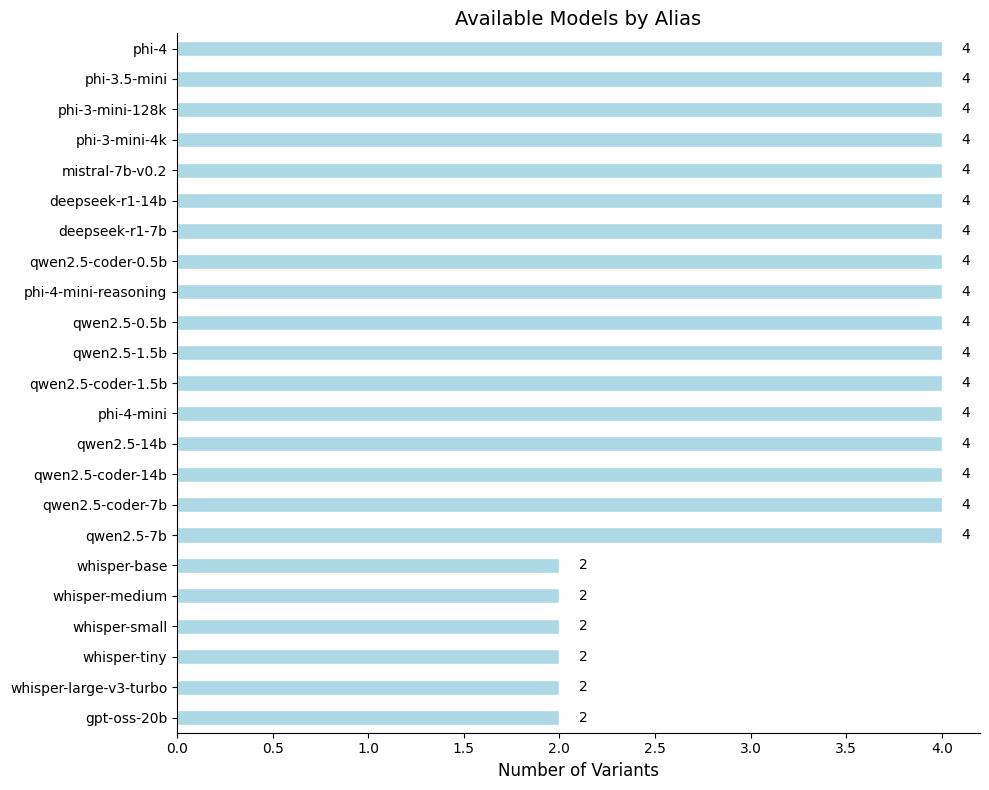

In [21]:
plot_value_counts(df_catalog,
                  "alias",
                  title="Available Models by Alias",
                  xlabel="Number of Variants",
                  figsize=(10, 8),
                  color="lightblue")

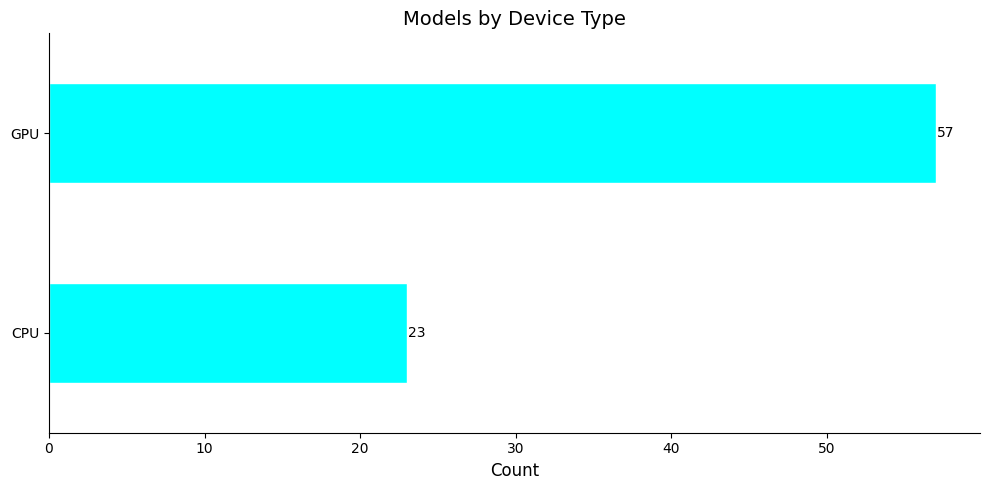

In [22]:
plot_value_counts(df_catalog,
                  "device",
                  title="Models by Device Type",
                  xlabel="Count",
                  color="cyan")

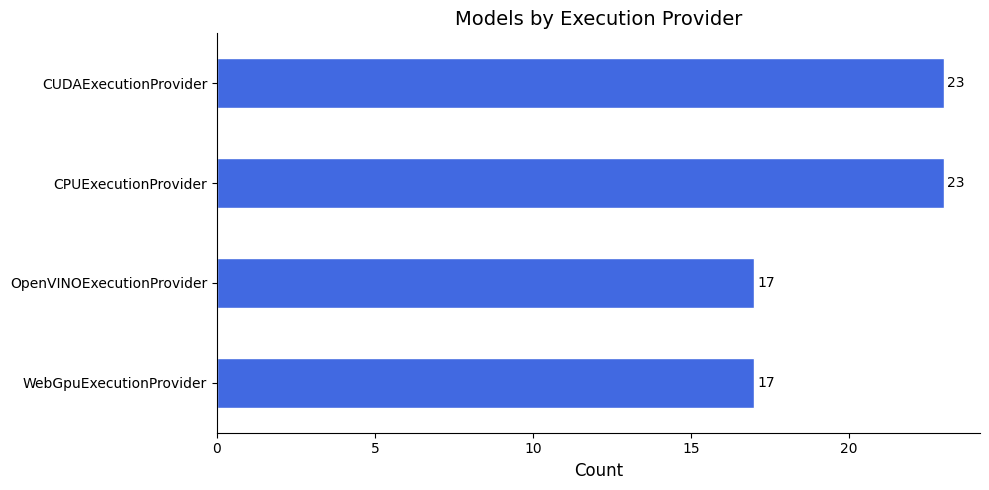

In [23]:
plot_value_counts(df_catalog,
                  "provider",
                  title="Models by Execution Provider",
                  xlabel="Count",
                  color="royalblue")

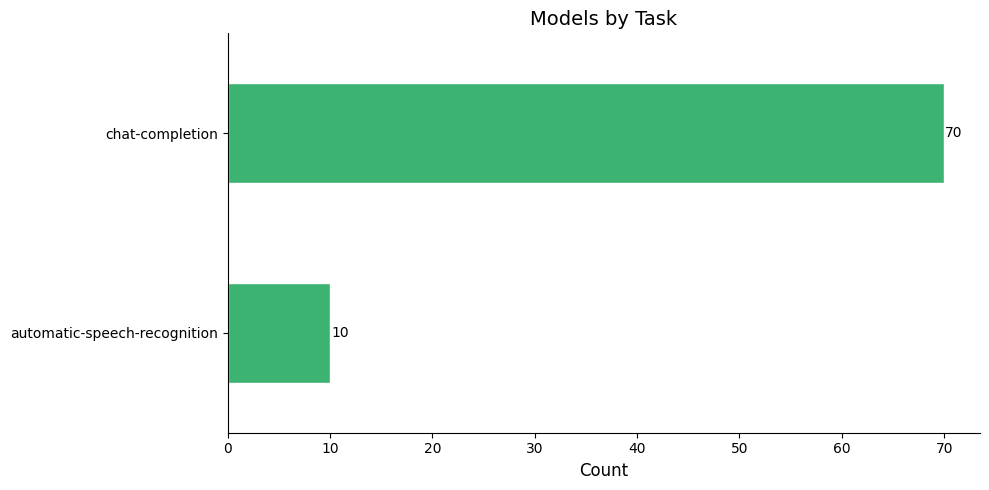

In [24]:
plot_value_counts(df_catalog,
                  "task",
                  title="Models by Task",
                  xlabel="Count",
                  color="mediumseagreen")

## Cache Management

Downloaded models are stored in the local cache. This avoids re-downloading models each time you load them.

In [25]:
cached = manager.list_cached_models()
print(f"Cached models = {len(cached)}")

df_cached = models_to_df(cached)
df_cached

Cached models = 0


""


## Inference with OpenAI SDK

Foundry Local exposes an **OpenAI-compatible** endpoint, so you can use the standard `openai` Python package.

**Workflow:**
1. Load a model into the inference engine with `manager.load_model()`
2. Create an `OpenAI` client pointing to the local endpoint
3. Call `client.chat.completions.create()` using the model **ID string**

**Tip:** Always pass `model_info.id` (a string) to the OpenAI client, not the model object itself.

### 1. Using phi-4

> https://huggingface.co/microsoft/phi-4

In [26]:
def test_download_speed(url="http://speedtest.tele2.net/100MB.zip"):
    print("Testing your download speed...\n")
    start = time.time()
    response = requests.get(url, stream=False)
    elapsed = time.time() - start
    
    size_mb = len(response.content) / 1_000_000
    speed_mbps = (size_mb * 8) / elapsed  # Convert MB to Megabits
    
    print(f"- Downloaded: {size_mb:.2f} MB in {elapsed:.2f}s")
    print(f"- Speed:      {speed_mbps:.2f} Mbps")

test_download_speed()

Testing your download speed...

- Downloaded: 104.86 MB in 41.72s
- Speed:      20.11 Mbps


In [27]:
manager.download_model("Phi-4-mini")  # it will download the best model according to your infra

FoundryModelInfo(alias=phi-4-mini, id=Phi-4-mini-instruct-cuda-gpu:5, execution_provider=CUDAExecutionProvider, device_type=GPU, file_size=3686 MB, license=MIT)

In [28]:
os.listdir(os.path.join(manager.get_cache_location(), "Microsoft"))

['Phi-4-mini-instruct-cuda-gpu-5']

In [29]:
# Load a model into memory
model_info = manager.load_model("Phi-4-mini")
print(f"Loaded: {model_info.alias} => {model_info.id}")

Loaded: phi-4-mini => Phi-4-mini-instruct-cuda-gpu:5


In [30]:
info = manager.get_model_info("Phi-4-mini")
print(f"Running on: {info.execution_provider}")
print(f"Device:     {info.device_type}")

Running on: CUDAExecutionProvider
Device:     GPU


In [31]:
# Initialize the OpenAI client
client = OpenAI(base_url=manager.endpoint, api_key=manager.api_key)

In [32]:
# Run a simple chat completion
response = client.chat.completions.create(model=model_info.id,
                                          messages=[{
                                              "role": "user",
                                              "content": "Hello, who are you?"
                                          }])

print(response.choices[0].message.content)

Hello! I am Phi developed by Microsoft, an AI designed to assist with a wide range of tasks and answer questions to the best of my ability. How can I help you today?


In [33]:
# Inspect the full response object
print(f"Model used : {response.model}")
print(f"Finish     : {response.choices[0].finish_reason}")

Model used : Phi-4-mini-instruct-cuda-gpu:5
Finish     : stop


### 2. Using gpt-oss-20b

You can load multiple models simultaneously (memory permitting) and switch between them.

> https://huggingface.co/openai/gpt-oss-20b

In [34]:
# Filter by alias keyword
df_catalog[df_catalog["alias"].str.contains("gpt-oss-20b", case=False, na=False)]

,alias,id,device,provider,size_mb,tools,license,task
78,gpt-oss-20b,gpt-oss-20b-generic-cpu:1,CPU,CPUExecutionProvider,12552,False,MIT,chat-completion
79,gpt-oss-20b,gpt-oss-20b-cuda-gpu:1,GPU,CUDAExecutionProvider,9882,False,apache-2.0,chat-completion


In [35]:
manager.download_model("gpt-oss-20b")

FoundryModelInfo(alias=gpt-oss-20b, id=gpt-oss-20b-generic-cpu:1, execution_provider=CPUExecutionProvider, device_type=CPU, file_size=12552 MB, license=MIT)

In [36]:
os.listdir(os.path.join(manager.get_cache_location(), "Microsoft"))

['gpt-oss-20b-generic-cpu-1', 'Phi-4-mini-instruct-cuda-gpu-5']

In [37]:
# Load a second model
model_info_2 = manager.load_model("gpt-oss-20b")
print(f"Loaded: {model_info_2.alias} => {model_info_2.id}")

Loaded: gpt-oss-20b => gpt-oss-20b-generic-cpu:1


In [38]:
info = manager.get_model_info("gpt-oss-20b")
print(f"Running on: {info.execution_provider}")
print(f"Device:     {info.device_type}")

Running on: CPUExecutionProvider
Device:     CPU


In [39]:
response_2 = client.chat.completions.create(
    model=model_info_2.id,
    messages=[{
        "role": "user",
        "content": "What is the capital of France?"
    }])

print(f"Model: {response_2.model}")
print(response_2.choices[0].message.content)

Model: gpt-oss-20b-generic-cpu:1
<|channel|>analysis<|message|>We have to answer a straightforward question. The user asks: "What is the capital of France?" The answer: "Paris." Simple.<|end|><|start|>assistant<|channel|>final<|message|>The capital of France is **Paris**.


## Loaded Models

Check which models are currently loaded in the inference engine.

In [40]:
loaded = manager.list_loaded_models()

In [41]:
df_loaded = pd.DataFrame([{
    "alias": m.alias,
    "id": m.id,
    "device": m.device_type.value,
    "size_mb": m.file_size_mb,
    "tools_support": m.supports_tool_calling,
} for m in loaded])

display(df_loaded)

,alias,id,device,size_mb,tools_support
0,phi-4-mini,Phi-4-mini-instruct-cuda-gpu:5,GPU,3686,True
1,gpt-oss-20b,gpt-oss-20b-generic-cpu:1,CPU,12552,False


## Cleanup

Unload models to free up memory when you're done. 
This does **not** delete them from the cache — they can be reloaded instantly.

In [42]:
print(manager.get_cache_location())

C:\models


In [43]:
# List cached models
cached = manager.list_cached_models()
for m in cached:
    print(f"Cached model: {m.id}")

Cached model: gpt-oss-20b-generic-cpu:1
Cached model: Phi-4-mini-instruct-cuda-gpu:5


In [44]:
# Unload all currently loaded models
for m in manager.list_loaded_models():
    print(f"Unloading model '{m.id}'")
    manager.unload_model(m.id)

Unloading model 'Phi-4-mini-instruct-cuda-gpu:5'
Unloading model 'gpt-oss-20b-generic-cpu:1'


In [45]:
os.listdir(os.path.join(manager.get_cache_location(), "Microsoft"))

['gpt-oss-20b-generic-cpu-1', 'Phi-4-mini-instruct-cuda-gpu-5']

In [47]:
shutil.rmtree(os.path.join(manager.get_cache_location(), "Microsoft", "gpt-oss-20b-generic-cpu-1"))
shutil.rmtree(os.path.join(manager.get_cache_location(), "Microsoft", "Phi-4-mini-instruct-cuda-gpu-5"))

In [48]:
os.listdir(os.path.join(manager.get_cache_location(), "Microsoft"))

[]

# What We Learned: Running Microsoft Foundry Local

---

## 1. Foundry Local Basics

- Microsoft Foundry Local lets us run AI models entirely on local hardware using **ONNX Runtime**.
- It exposes an **OpenAI-compatible API**, so existing OpenAI SDK–based code works by simply changing the endpoint.
- No internet connection is required once models are downloaded.

---

## 2. Why Foundry Local Matters

| Benefit | Description |
|---|---|
| 🔒 **Privacy & data sovereignty** | All inference stays on the local machine |
| 💸 **Zero runtime cost** | No API calls, no per-token billing after models are cached |
| ⚡ **Low latency & offline support** | No network round-trips |
| 🖥️ **Optimized for consumer hardware** | Works on CPUs and modest GPUs (CUDA, OpenVINO, WebGPU) |
| ☁️ **Smooth cloud migration** | Local prototyping aligns with Azure AI Foundry for later scaling |

---

## 3. Environment & Hardware Inspection

The notebook captures detailed system info to determine which model variants are best suited for the machine:

- OS, CPU, RAM, disk usage
- GPU availability and utilization

---

## 4. Foundry Local Service

`FoundryLocalManager` handles the full service lifecycle:

- Starts a local inference service
- Exposes:
  - Service URI (e.g. `http://127.0.0.1:<port>`)
  - OpenAI-compatible endpoint (`/v1`)
  - Local model cache location
- Automatically manages model loading and unloading

---

## 5. Model Catalog Exploration

The Foundry catalog contains **multiple variants per model**, optimized for different devices.

**Available model families:**

| Family | Models |
|---|---|
| **Phi** | Phi-4, Phi-4-mini, Phi-3.5, … |
| **Other LLMs** | Qwen, Mistral, DeepSeek, gpt-oss-20b |
| **Speech** | Whisper (speech-to-text) |

**Each catalog entry includes:**

- Alias and full model ID
- Device type (CPU / GPU)
- Execution provider (CUDA, OpenVINO, CPU)
- Size, license, supported tasks, tool-calling support

**The catalog can be:**

- Filtered by alias, device type, or task
- Visualized (distribution by device, provider, task)
- Exported (e.g. to Excel)

---

## 6. Cache Management

- Downloaded models are stored locally and **reused across sessions**.
- Cached models do not need to be re-downloaded when reloaded.

> ⚠️ **Important distinction:**
> - **Cached** → stored on disk
> - **Loaded** → active in memory

---

## 7. Running Inference with the OpenAI SDK

Standard OpenAI Python client works by pointing to the local endpoint:

```python
client = OpenAI(
    base_url=manager.endpoint,
    api_key=manager.api_key
)
```

> 🔑 **Key rule:** Always pass `model_info.id` (not the alias) to the client.

**Examples from the notebook:**
- Loaded Phi-4 (GPU) and successfully ran a chat completion
- Loaded gpt-oss-20b (CPU) in parallel and switched models seamlessly

---

## 8. Multi-Model Support

Multiple models can be loaded simultaneously (memory permitting). You can:

- List all loaded models
- Inspect which device/provider each one uses
- Switch models per request

---

## 9. Cleanup & Resource Control

- Models can be **unloaded from memory** without deleting them from disk.
- This frees RAM/VRAM while keeping reloads fast.

---

## 10. Key Takeaway

> Foundry Local enables **fully local, cost-free, privacy-preserving AI development** with a cloud-like developer experience.
> No GPU required, no internet needed — just download, load, and build.

> Go to next notebook